## Phase 4: Statistical EDA
### Part 1: Univariate Analysis

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_filtered = pd.read_pickle("../data/cleaned_data.pkl")
df_filtered.head()

,id,title,company_name,category_label,category_tag,country,location_display,location_area,latitude,longitude,contract_type,contract_time,salary_min,salary_max,salary_mid,salary_is_predicted,created_dt,created_date,redirect_url,adref
0,5410474609,Mechanical Pipefitter,Dodd Group,Trade & Construction Jobs,trade-construction-jobs,United Kingdom,"King's Lynn, Norfolk",UK > Eastern England > Norfolk > King's Lynn,52.751999,0.395357,permanent,full_time,40518.74,40518.74,40518.74,1,2025-09-22 09:28:13+00:00,2025-09-22,https://www.adzuna.co.uk/jobs/details/54104746...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQxMDQ3NDYwOSIsI...
1,5381519011,International Trade Policy Editor [Startup Pol...,Applio Ventures,Graduate Jobs,graduate-jobs,United Kingdom,"London, UK",UK > London,NaN,NaN,permanent,full_time,64000.00,64000.00,64000.00,0,2025-09-03 21:20:59+00:00,2025-09-03,https://www.adzuna.co.uk/jobs/details/53815190...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4MTUxOTAxMSIsI...
3,5403097985,Early Years BABY Room Leader,Jesters Childcare Essex,Teaching Jobs,teaching-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,26707.00,29494.00,28100.50,0,2025-09-17 15:00:12+00:00,2025-09-17,https://www.adzuna.co.uk/jobs/details/54030979...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwMzA5Nzk4NSIsI...
5,5404665589,Computer Systems Validation specialist,North Star Consulting UK,Scientific & QA Jobs,scientific-qa-jobs,United Kingdom,"Newcastle Upon Tyne, Tyne & Wear",UK > North East England > Tyne & Wear > Newcas...,NaN,NaN,permanent,full_time,65000.00,65000.00,65000.00,0,2025-09-18 10:29:32+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54046655...,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiRWtwZjc5cWI4QkdZM...
6,5404864465,Full Stack Software Engineer,Marshall Wolfe Ltd,IT Jobs,it-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,0.00,60000.00,30000.00,0,2025-09-18 14:32:46+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54048644...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwNDg2NDQ2NSIsI...


In [3]:
# View relevant statistics for salary categories
print(df_filtered.nunique())
print(df_filtered[['salary_min', 'salary_max', 'salary_mid']].describe())

id                     1345
title                  1063
company_name            624
category_label           67
category_tag             30
country                   8
location_display        964
location_area           964
latitude                963
longitude               963
contract_type             2
contract_time             2
salary_min              795
salary_max              807
salary_mid              916
salary_is_predicted       2
created_dt             1096
created_date            211
redirect_url           1345
adref                  1346
dtype: int64
          salary_min     salary_max     salary_mid
count    1346.000000    1346.000000    1346.000000
mean    47527.442578   53017.268730   50272.355654
std     35305.787348   37694.082998   35959.681985
min         0.000000    1000.000000     601.000000
25%     26028.625000   30000.000000   28000.000000
50%     38425.450000   45020.925000   41791.315000
75%     59281.612500   65000.000000   61094.892500
max    384000.00000

Value Counts for each job description:

category_tag
healthcare-nursing-jobs          224
unknown                          221
teaching-jobs                    119
customer-services-jobs            92
logistics-warehouse-jobs          90
engineering-jobs                  77
trade-construction-jobs           59
it-jobs                           55
travel-jobs                       52
sales-jobs                        51
social-work-jobs                  50
hospitality-catering-jobs         40
manufacturing-jobs                34
accounting-finance-jobs           30
admin-jobs                        18
legal-jobs                        17
part-time-jobs                    16
retail-jobs                       16
maintenance-jobs                  14
pr-advertising-marketing-jobs     11
other-general-jobs                11
creative-design-jobs              10
domestic-help-cleaning-jobs       10
graduate-jobs                     10
consultancy-jobs                   5
hr-jobs               

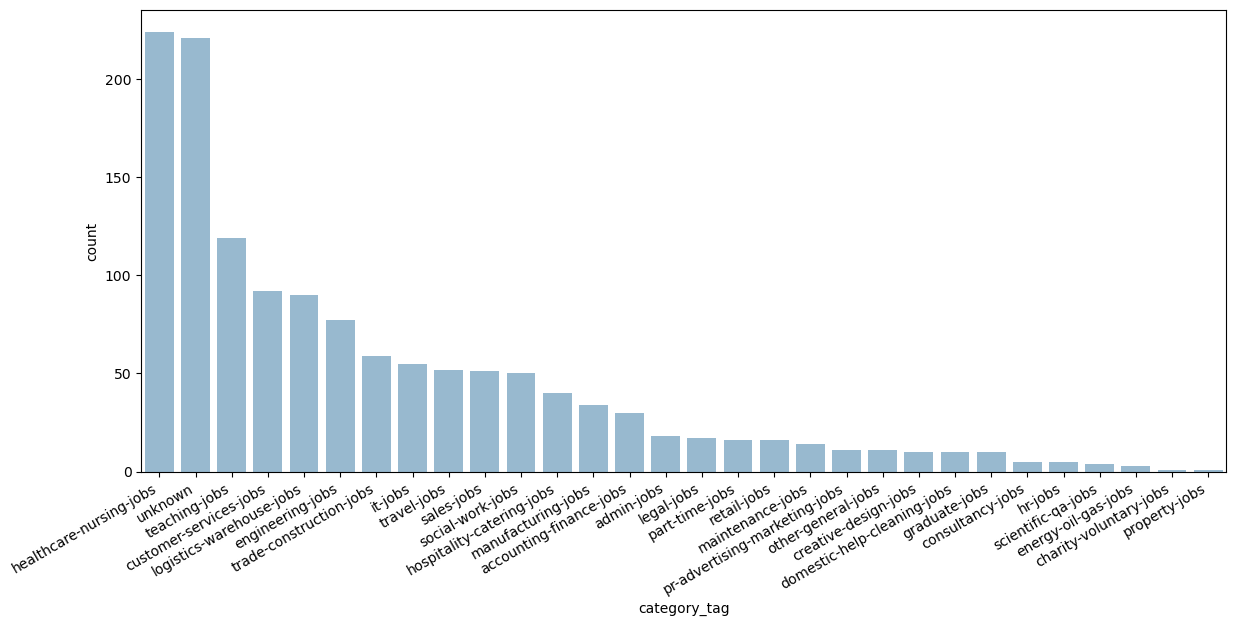

In [13]:
# Visualize the spread of job types
#sns.countplot(data = df_filtered, x = 'category_tag', alpha = 0.5)
#plt.xticks(rotation=30, ha='right')

# Set a wider figure size to spread out the bars
plt.figure(figsize=(14, 6))  

# sort categories by frequency
sorted_tags = df_filtered['category_tag'].value_counts().index

# Create the countplot with sorted categories
sns.countplot(data=df_filtered, x='category_tag', order=sorted_tags, alpha=0.5)

# Rotate x-axis labels for clarity
plt.xticks(rotation=30, ha='right')

print(f'Value Counts for each job description:\n\n{df_filtered['category_tag'].value_counts()}')

Healthcare accounts for the vast majority of job types with teaching, customer service, logistics, and engineering jobs accounting for another majority
It will be important to compare salary levels across these job types and make sure to account for low frequency jobs and their salaries in any consideration.

Value Counts for each job description:

country
USA               499
United Kingdom    480
Netherlands       129
France             92
Spain              88
Italy              43
Switzerland         8
Germany             7
Name: count, dtype: int64


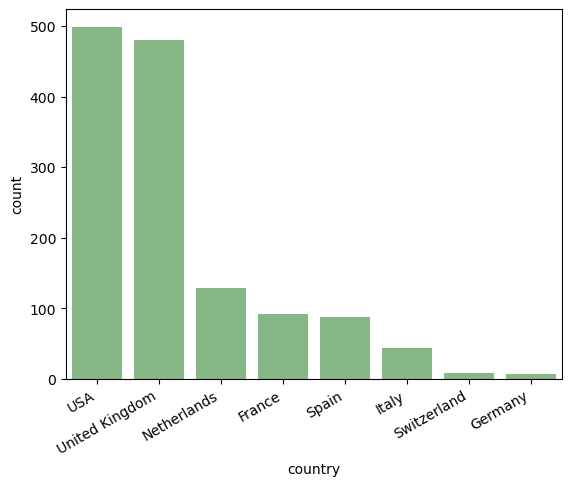

In [17]:
# Visualize the distribution of job locations

# sort countries by frequency
sorted_countries = df_filtered['country'].value_counts().index
ax = sns.countplot(data=df_filtered, x='country', color='Green', alpha=0.5, order = sorted_countries)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')


print(f'Value Counts for each job description:\n\n{df_filtered['country'].value_counts()}')

Univariate analysis was duplicated from the job description analysis for countries. The United States and United Kingdom represent the location where the majority of jobs are found. France Netherlands and Spain are also countries to consider in locating trends in the data.


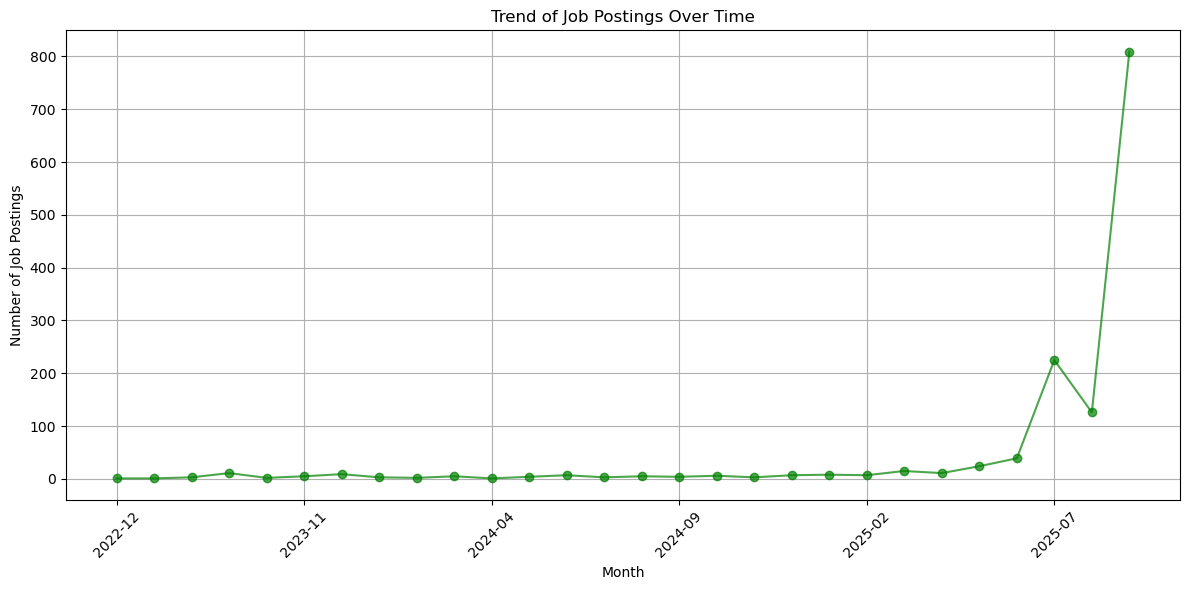

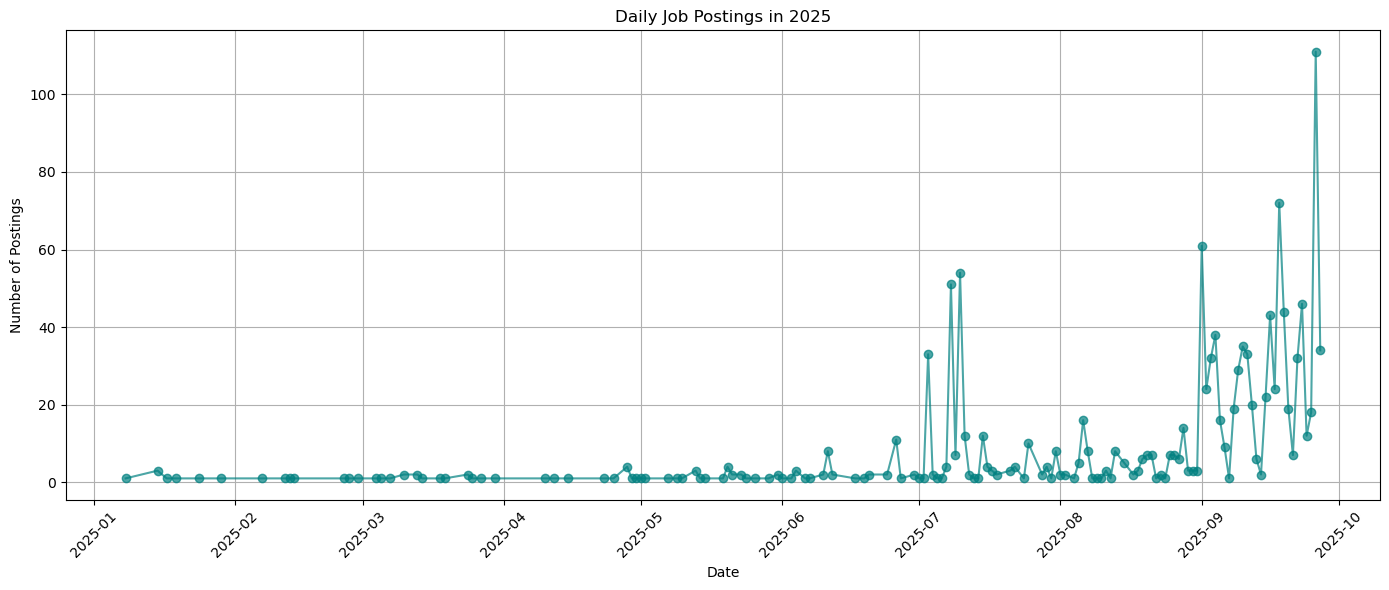

In [24]:
#Convertind created date to date time
df_filtered['created_date'] = pd.to_datetime(df_filtered['created_date'])

#Group by time period
df_filtered['created_month'] = df_filtered['created_date'].dt.to_period('M').astype(str)

# Count job postings per month
monthly_counts = df_filtered['created_month'].value_counts().sort_index()

# Plot the time series
plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o', color='green', alpha=0.7)

# Label the axes and title
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.title("Trend of Job Postings Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



# Filter for only 2025 dates
df_2025 = df_filtered[df_filtered['created_date'].dt.year == 2025]

# Count postings by exact date
daily_counts_2025 = df_2025['created_date'].dt.date.value_counts().sort_index()

# Plot the daily trend for 2025
plt.figure(figsize=(14, 6))
daily_counts_2025.plot(kind='line', color='teal', marker='o', alpha=0.7)
plt.title("Daily Job Postings in 2025")
plt.xlabel("Date")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



Initial observation of when jobs were posted was very skewed. This data was collected in 25, which made the original visualization very skewed, as very few jobs were found in the data from years before 2025. Even further before June of 2025, this trend continued. There was a heavy spike in job postings at the beginning of July 2025 and another large spike in the month of September, which saw the most consistently large number of jobs posted throughout the month. An exploration of how salaries posted during this time compare to salaries posted in other times.


After some outside research into this large jump, it can be attributed to a phenomenon called the September Surge, where employers begin a push in hiring with expected starts in the new year, as well as in an attempt to meet yearly objectives in filling positions (Royle). 

### Part 2: Bivariate Analysis

Descending sort of average minimum salary by job:
                                       mean           std           var
category_tag                                                           
healthcare-nursing-jobs        81303.923080  46495.020812  2.161787e+09
accounting-finance-jobs        71100.483333  75967.892929  5.771121e+09
legal-jobs                     69754.387647  46301.875898  2.143864e+09
it-jobs                        64791.864000  32370.047556  1.047820e+09
travel-jobs                    61821.350192  15487.669114  2.398679e+08
scientific-qa-jobs             61565.325000  16135.025710  2.603391e+08
part-time-jobs                 60914.430625  42890.483824  1.839594e+09
property-jobs                  60000.000000           NaN           NaN
energy-oil-gas-jobs            53185.106667   2980.926359  8.885922e+06
sales-jobs                     52564.035098  26876.459066  7.223441e+08
trade-construction-jobs        50801.107119  25153.894424  6.327184e+08
engineering-jo

<Axes: xlabel='salary_min', ylabel='category_tag'>

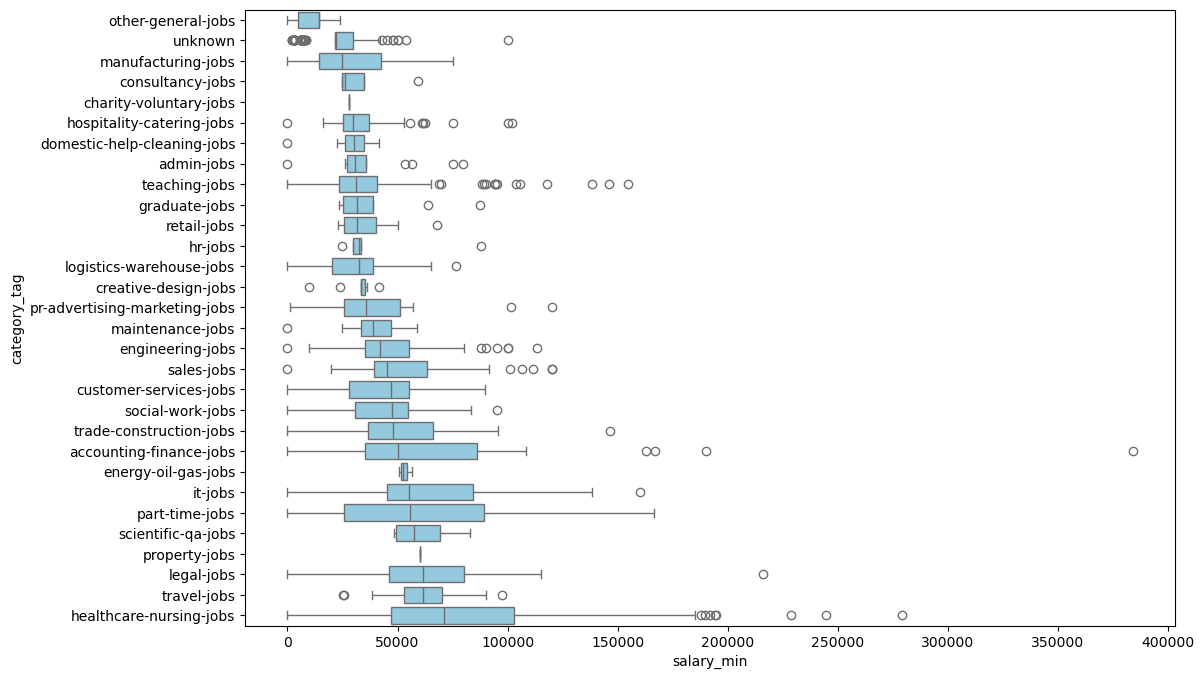

In [33]:
# Group salary by job type
df_job_type = df_filtered.groupby('category_tag')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by job:")
print(df_job_type['salary_min'].sort_values(by = 'mean', ascending = False))

#Constructing box plot
plt.figure(figsize=(12, 8))  # Make the figure larger for readability

#original code 
#sns.boxplot(data = df_filtered, x = 'salary_min', y = 'category_tag')
order = df_filtered.groupby('category_tag')['salary_min'].median().sort_values().index

#Graph improved with copilot for clarity
sns.boxplot(data=df_filtered, x='salary_min', y='category_tag', order=order, color='skyblue')


Descending sort of average maximum salary by job:
                                       mean           std           var
category_tag                                                           
accounting-finance-jobs        87455.350000  93432.927392  8.729712e+09
healthcare-nursing-jobs        87134.088259  50423.392669  2.542519e+09
legal-jobs                     86272.034706  46104.067059  2.125585e+09
it-jobs                        71933.518545  29159.150510  8.502561e+08
scientific-qa-jobs             70815.325000  33634.967489  1.131311e+09
property-jobs                  70000.000000           NaN           NaN
part-time-jobs                 65769.180625  39410.555632  1.553192e+09
travel-jobs                    61951.504038  15305.312497  2.342526e+08
energy-oil-gas-jobs            61585.106667  17366.094378  3.015812e+08
trade-construction-jobs        58158.395254  21968.951870  4.826348e+08
sales-jobs                     55912.074314  28751.078037  8.266245e+08
engineering-jo

<Axes: xlabel='salary_max', ylabel='category_tag'>

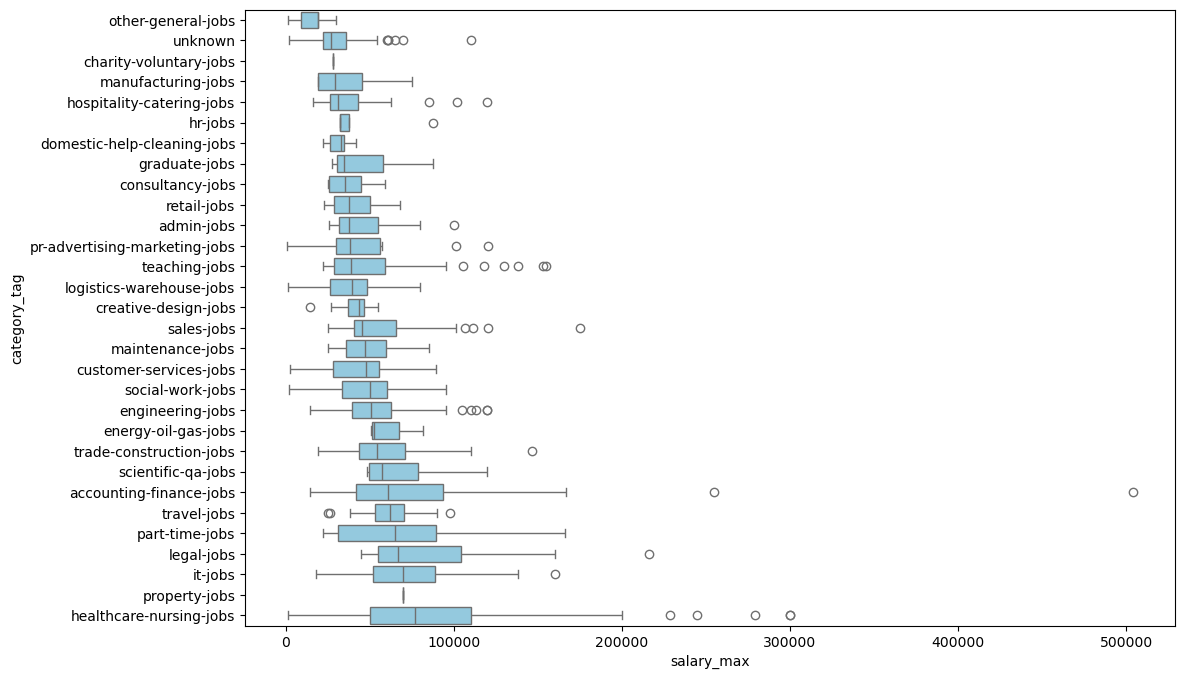

In [34]:
print("Descending sort of average maximum salary by job:")
print(df_job_type['salary_max'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_max', y = 'category_tag')

plt.figure(figsize=(12, 8))

# Sort categories by median salary_max 
order = df_filtered.groupby('category_tag')['salary_max'].median().sort_values().index

# Clean boxplot with single color 
sns.boxplot(
    data=df_filtered,
    x='salary_max',
    y='category_tag',
    order=order,
    color='skyblue' 
)


Descending sort of average minimum salary by country:
                        mean           std           var
country                                                 
USA             72953.445812  37795.429226  1.428494e+09
Germany         70428.571429  41287.032439  1.704619e+09
Switzerland     45875.000000  21675.776473  4.698393e+08
United Kingdom  36570.604688  19230.741123  3.698214e+08
Netherlands     33779.527132  19102.163210  3.648926e+08
France          28919.565217  39327.791921  1.546675e+09
Italy           17106.976744   9003.528286  8.106352e+07
Spain           15914.988636  13453.433335  1.809949e+08


<Axes: xlabel='salary_min', ylabel='country'>

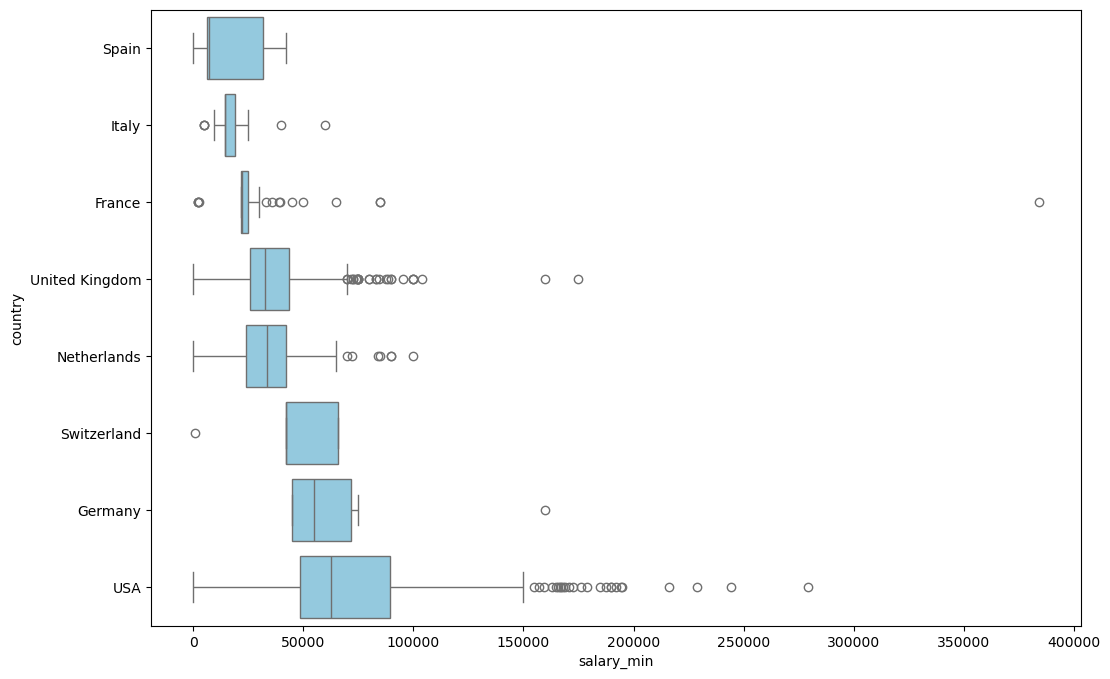

In [35]:
# Repeat for location
df_location = df_filtered.groupby('country')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_min', y = 'country')

plt.figure(figsize=(12, 8))

# Sort countries by median salary_min
order = df_filtered.groupby('country')['salary_min'].median().sort_values().index

# Clean boxplot
sns.boxplot(
    data=df_filtered,
    x='salary_min',
    y='country',
    order=order,
    color='skyblue')

Descending sort of average maximum salary by country:
                        mean           std           var
country                                                 
USA             72953.445812  37795.429226  1.428494e+09
Germany         70428.571429  41287.032439  1.704619e+09
Switzerland     45875.000000  21675.776473  4.698393e+08
United Kingdom  36570.604688  19230.741123  3.698214e+08
Netherlands     33779.527132  19102.163210  3.648926e+08
France          28919.565217  39327.791921  1.546675e+09
Italy           17106.976744   9003.528286  8.106352e+07
Spain           15914.988636  13453.433335  1.809949e+08


<Axes: xlabel='salary_max', ylabel='country'>

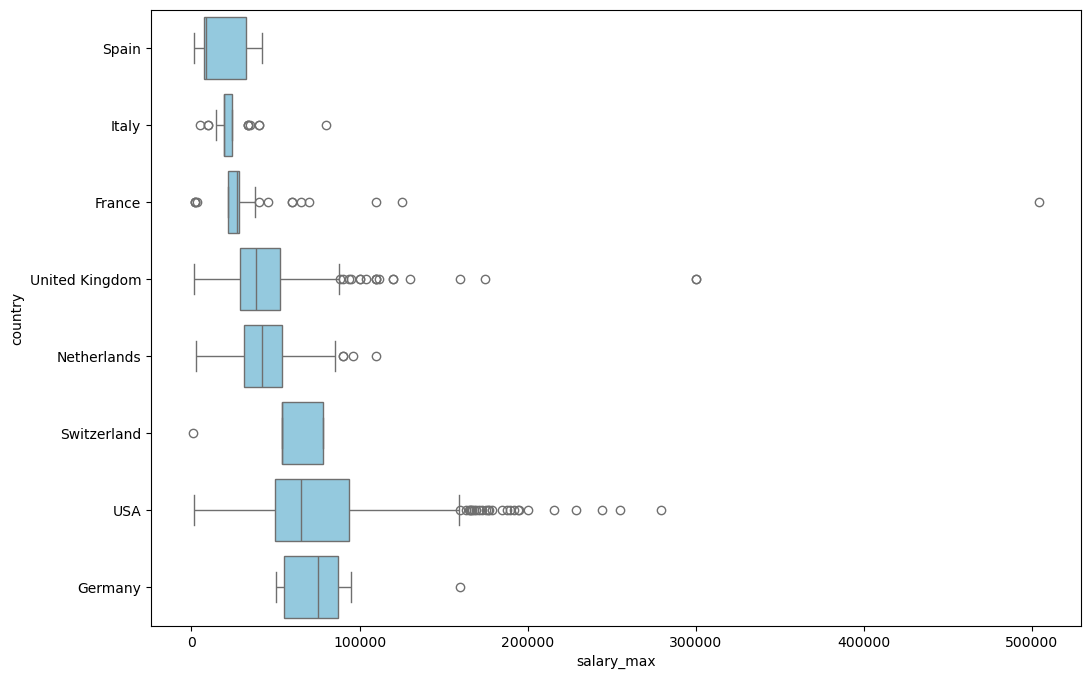

In [36]:
# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average maximum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

#sns.boxplot(data = df_filtered, x = 'salary_max', y = 'country')

plt.figure(figsize=(12, 8))

# Sort countries by median salary_max
order = df_filtered.groupby('country')['salary_max'].median().sort_values().index

# Clean boxplot with single color
sns.boxplot(
    data=df_filtered,
    x='salary_max',
    y='country',
    order=order,
    color='skyblue')

In [29]:
jobs_by_country = pd.crosstab(index = df_filtered['category_tag'], columns = df_filtered['country'])

german_jobs = jobs_by_country[(jobs_by_country['Germany'] != 0)]
german_jobs

country,France,Germany,Italy,Netherlands,Spain,Switzerland,USA,United Kingdom
category_tag,,,,,,,,
healthcare-nursing-jobs,2,2,3,0,0,1,178,38
it-jobs,0,5,1,7,0,1,12,29


Salary statistics comparing September vs. other months:

                salary_min                                             \
                      mean   median           std           var count   
is_september                                                            
False         48953.805977  37320.0  37953.217445  1.440447e+09   522   
True          46623.848289  39000.0  33513.079523  1.123126e+09   824   

                salary_max                                               \
                      mean     median           std           var count   
is_september                                                              
False         53515.014789  45020.925  38928.014373  1.515390e+09   522   
True          52701.949017  45050.730  36911.529886  1.362461e+09   824   

                salary_mid                                               
                      mean     median           std           var count  
is_september                                         

<Axes: xlabel='is_september', ylabel='salary_mid'>

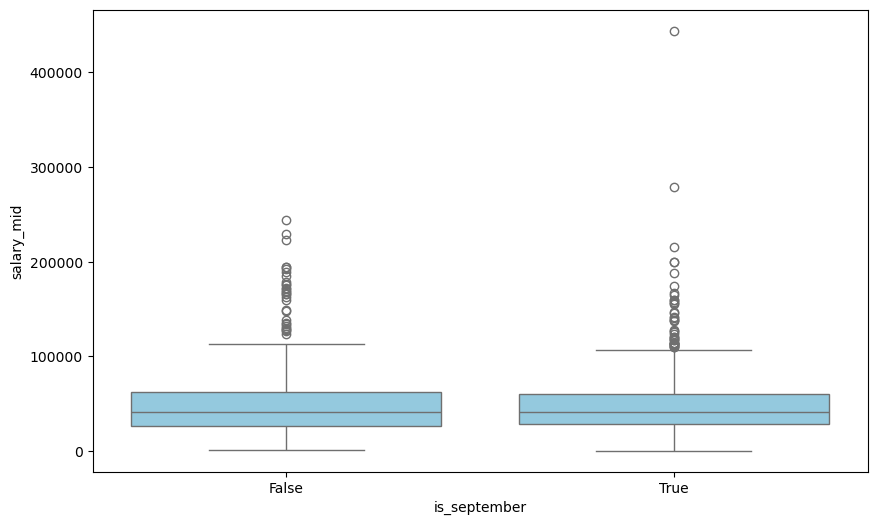

In [37]:
# Ensure created_date is datetime
df_filtered['created_date'] = pd.to_datetime(df_filtered['created_date'], errors='coerce')

# Flag september postings
df_filtered['is_september'] = df_filtered['created_date'].dt.month == 9

# Salary: September vs other months
salary_stats = df_filtered.groupby('is_september')[['salary_min', 'salary_max', 'salary_mid']].agg(
    ['mean','median', 'std', 'var', 'count']
)
print("Salary statistics comparing September vs. other months:\n")
print(salary_stats)

# visualize
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_filtered,
    x='is_september',
    y='salary_mid',
    color='skyblue')

It appears there is no real difference in salaries posted in september vs other months. The Box-Whisker plot reveals nearly identicle quartiles and median salaries. However, it does look like there are a few more high end outliers in September which may indicate a higher amount of large compensation jobs posted in September. 

### Part 3: Multivariate Analysis

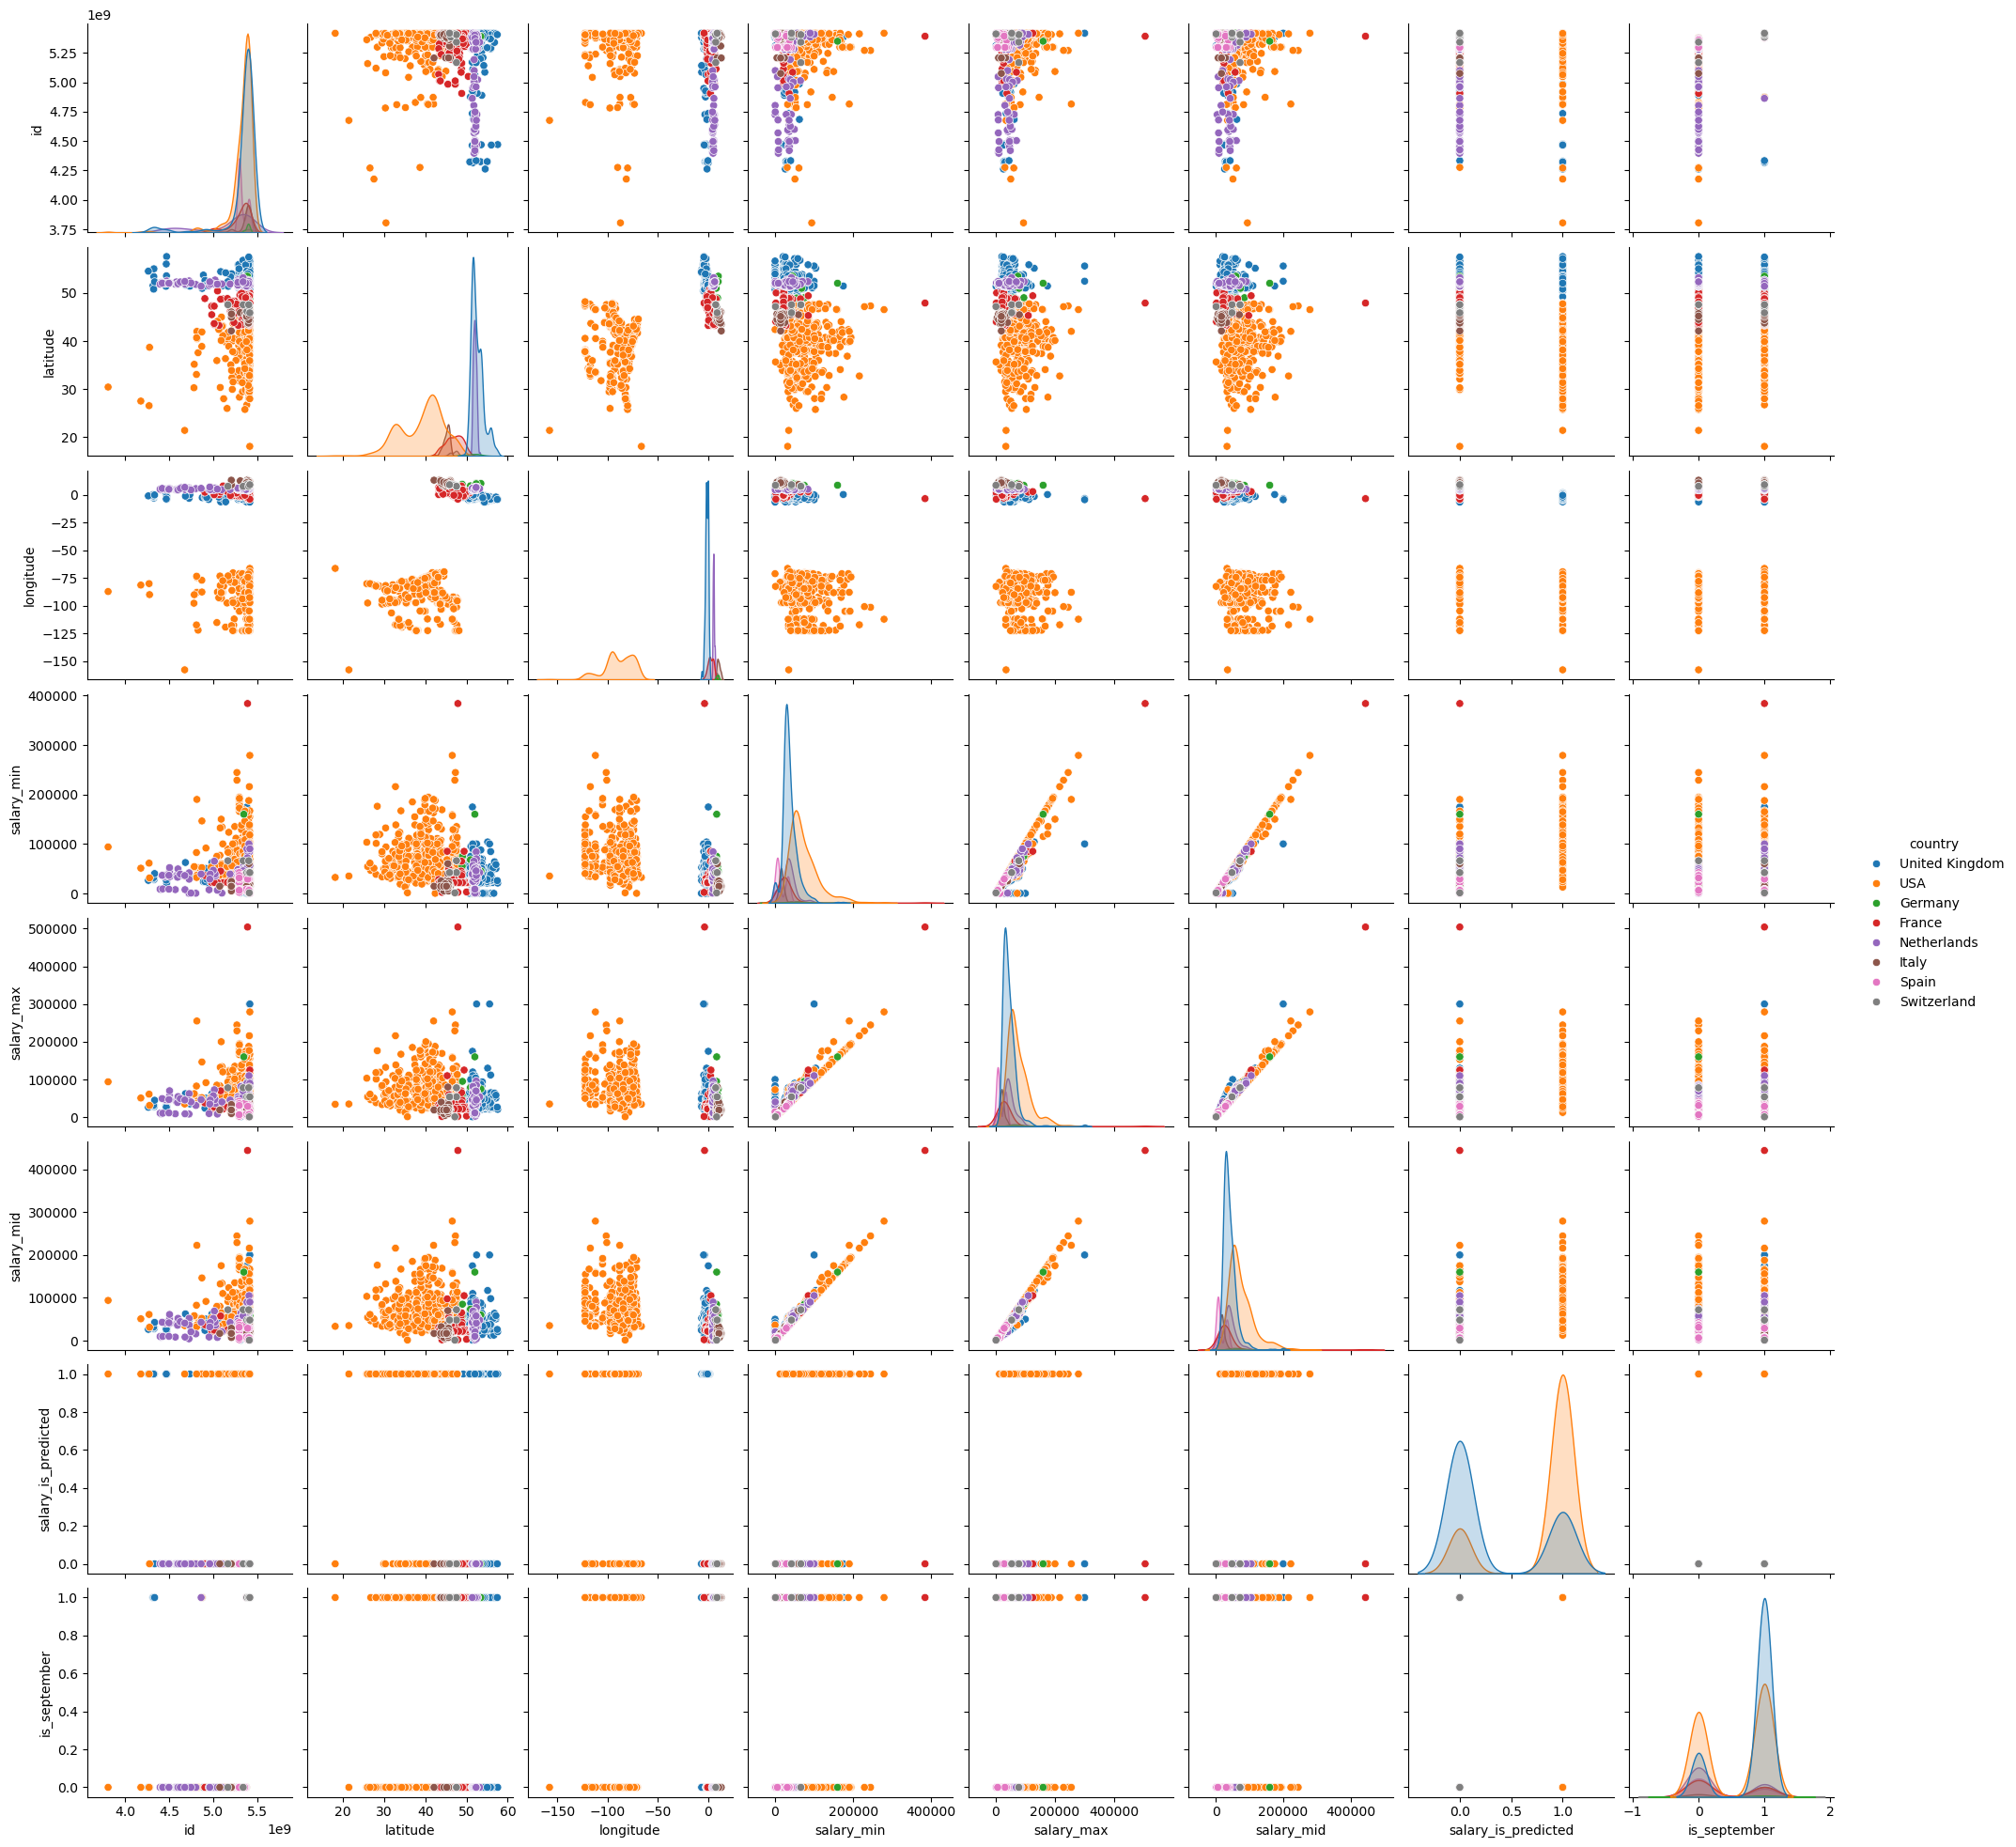

In [41]:
sns.pairplot(df_filtered, hue = 'country')

<Axes: xlabel='category_tag', ylabel='salary_mid'>

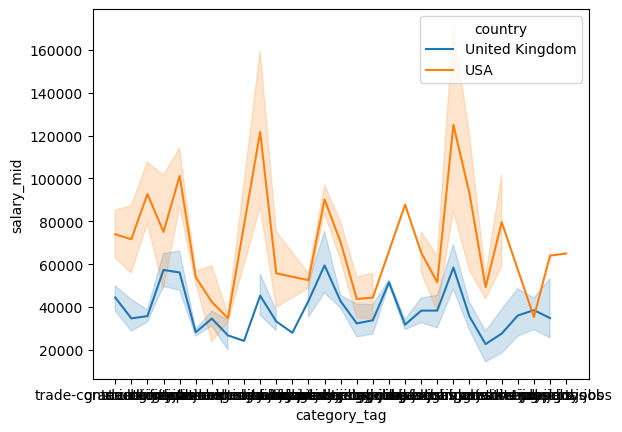

In [42]:
us_uk = df_filtered[(df_filtered['country'] == 'United Kingdom') | (df_filtered['country'] == 'USA')]
us_uk


sns.lineplot(data = us_uk, x = 'category_tag', y = 'salary_mid', hue = 'country')

### References

In [ ]:
Royle, Orianna Rosa. “The September Surge: Now Is the Best Time to Find a New
          Job, According to the Experts.” Fortune.Com, Sept. 2023, p. N.PAG. EBSCOhost,
          research.ebsco.com/linkprocessor/plink?id=1b989329-32f7-3910-88d8-4869d3238d0b.